In [79]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

(101, 101)


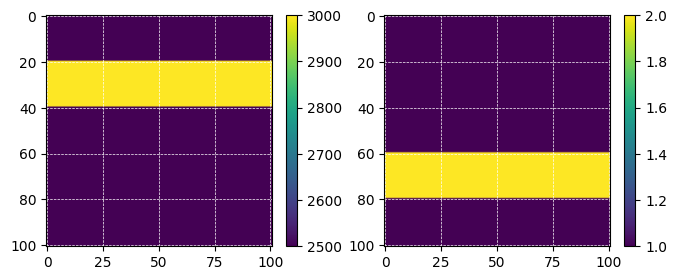

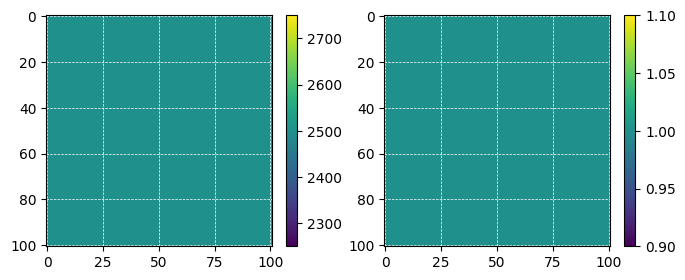

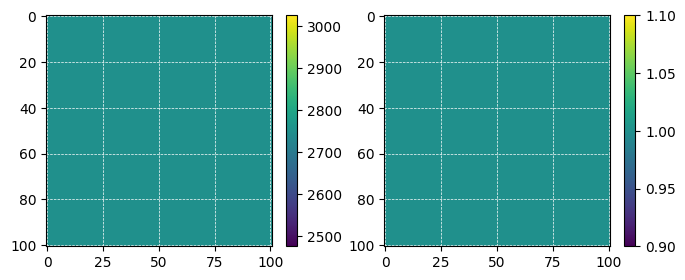

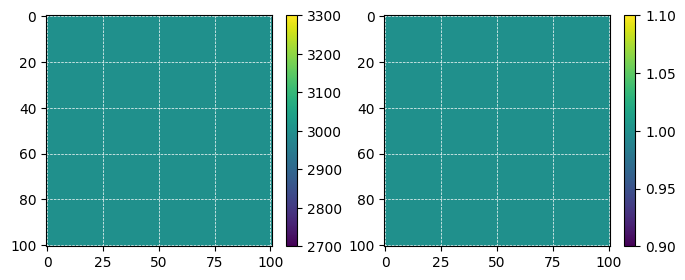

In [122]:
nz=101; nx=101
h=20  #500/20=25

vmin=2500; vmax=3000

nsnap=51; nzsnap=124; nxsnap=124

#5h=lambda=vmin/fmax
fmax=vmin/(5*h) #
fpeak=fmax/2.5  #10 Hz

#on time
dt=0.004
nt=500

ntr=100

#make model
vp=vmin*np.ones((nz,nx)); print(vp.shape)
vp[20:40,:]=vmax
vp.T.astype('float32').tofile('vp')

rho=np.ones((nz,nx))
rho[60:80,:]=2.
rho.T.astype('float32').tofile('rho')

!cat vp rho > true

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('true',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('true',(2*nx,nz))[:,nx:])

#make model
vp=vmin*np.ones((nz,nx))
vp.T.astype('float32').tofile('vp')

rho=np.ones((nz,nx))
rho.T.astype('float32').tofile('rho')

!cat vp rho > homo

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('homo',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('homo',(2*nx,nz))[:,nx:])

#make model
vp=(vmin+vmax)/2*np.ones((nz,nx))
vp.T.astype('float32').tofile('vp')

!cat vp rho > avg

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('avg',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('avg',(2*nx,nz))[:,nx:])

#make model
vp=vmax*np.ones((nz,nx))
vp.T.astype('float32').tofile('vp')

!cat vp rho > wrong

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('wrong',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('wrong',(2*nx,nz))[:,nx:])

In [90]:
def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=26):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/RTM',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

In [41]:
!cat setup_default

MODEL_SIZE              '101 101 1'
MODEL_SPACING            '20 20 1'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'vp rho'
FILE_TOPO               'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '20  20 0'
FR                      '20  20 0'
DR                      '0   20  0'
NR                      100

IF_HICKS                F

SCOMP                   p
RCOMP                   p #'p vz'

NT               500
DT               0.004


FPEAK            10
WAVELET_TYPE        'ricker'


#SNAPSHOT      'p'


## for RTM ##
FILE_DATA_PREFIX    'results_obs/Ru_Shot'

JOB           imaging

IF_USE_CHECKPOINT   F



## data

In [28]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2323456 Jun 26 13:54 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 3bc2a52
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2025
System time: 14:03:01
System timezone: +08:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.4

## SOCIG by RTM

### homo vel

In [100]:
!cp setup_default setup
!echo "FILE_MODEL  homo" >> setup
!echo "DIR_OUT     results_homo" >> setup
run(app='../../exe/rtm_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2556592 Jun 26 18:29 ../../exe/rtm_AC_FDSG_O4_
 Git Commit: 3bc2a52
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2025
System time: 19:40:58
System timezone: +08:00
                        
       WELCOME TO SeisJIMU RTM        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_rtm
 Output directory:results_rtm/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.4

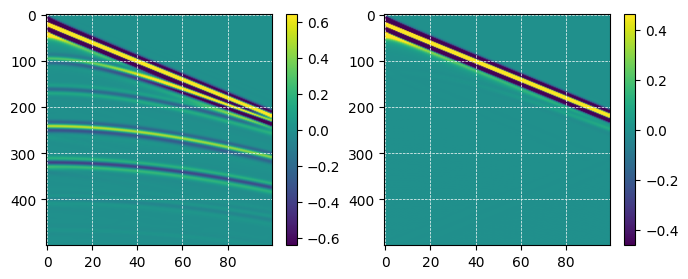

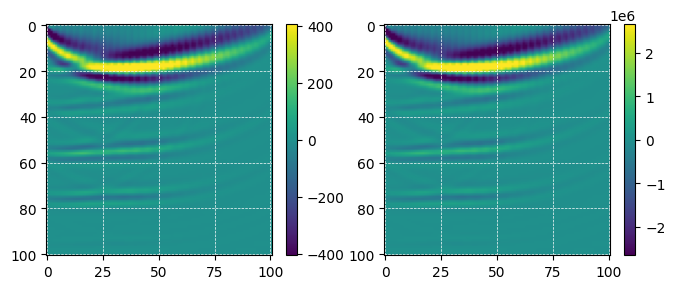

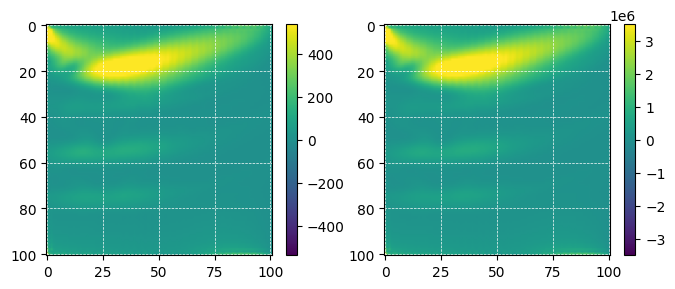

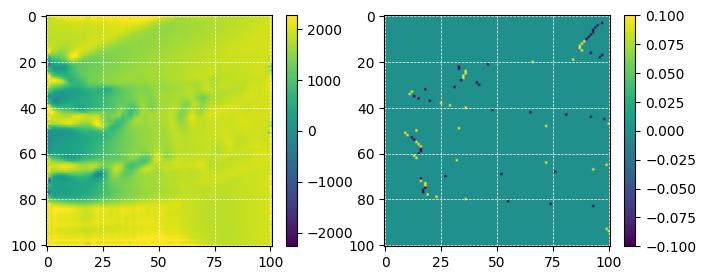

In [103]:
## plot
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read_su('./results_obs/Ru_Shot0001.su') ,perc=95)
plt.subplot(1,2,2); imshow(read_su('./results_homo/Ru_Shot0001.su'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_homo/a_star_u%ipp'),perc=98)
plt.subplot(1,2,2); imshow(read('results_homo/a2_star_u%ipp'),perc=98)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_homo/imag1'),perc=98)
plt.subplot(1,2,2); imshow(read('results_homo/imag2'),perc=98)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_homo/offset_map'),perc=98)
plt.subplot(1,2,2); imshow(read('results_homo/CIGs'),perc=98)

### lateral stack to mimic multi-shot case

In [76]:
RTMimage  = read('results_homo/a_star_u%ipp')
ATTRimage = read('results_homo/a2_star_u%ipp')

imag1=read('results_homo/imag1'); thres1=1e-6*np.max(imag1)
imag2=read('results_homo/imag2'); thres2=1e-6*np.max(imag2)

offset_map = read('results_homo/offset_map')
CIGs = read('results_homo/CIGs')

for ix in range(nx):
    for iz in range(nz):
        if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            ih = int(np.abs( offset_map[iz,ix]/h ) )
            print(iz,ix,ih)
            if ih<101:
                CIGs[iz,ih] += RTMimage[iz,ix]

0 0 92
1 0 93
2 0 91
3 0 91
4 0 89
5 0 89
6 0 89
7 0 88
8 0 91
9 0 95
10 0 99
11 0 101
12 0 94
13 0 95
14 0 104
15 0 107
16 0 88
17 0 56
18 0 45
19 0 39
20 0 26
21 0 92
22 0 36
23 0 53
24 0 32
25 0 80
26 0 156
27 0 99
28 0 71
29 0 59
30 0 63
31 0 108
32 0 90
33 0 75
34 0 42
35 0 1
36 0 37
37 0 48
38 0 43
39 0 90
40 0 146
41 0 147
42 0 189
43 0 96
44 0 186
45 0 89
46 0 63
47 0 46
48 0 570
49 0 72
50 0 16
51 0 51
52 0 0
53 0 12
54 0 16
55 0 2
56 0 0
57 0 4
58 0 9
59 0 5
60 0 24
61 0 46
62 0 80
63 0 87
64 0 95
65 0 64
66 0 71
67 0 79
68 0 89
69 0 67
70 0 79
71 0 89
72 0 178
73 0 35
74 0 45
75 0 27
76 0 33
77 0 84
78 0 92
79 0 60
80 0 73
81 0 75
82 0 89
83 0 89
84 0 91
85 0 90
86 0 91
87 0 87
88 0 89
89 0 88
90 0 89
91 0 87
92 0 90
93 0 88
94 0 88
95 0 85
96 0 90
97 0 90
98 0 91
99 0 88
100 0 91
0 1 158
1 1 83
2 1 92
3 1 95
4 1 94
5 1 95
6 1 93
7 1 92
8 1 90
9 1 88
10 1 88
11 1 88
12 1 92
13 1 97
14 1 101
15 1 113
16 1 110
17 1 65
18 1 35
19 1 26
20 1 0
21 1 39
22 1 12
23 1 41
24 1 34
25 1

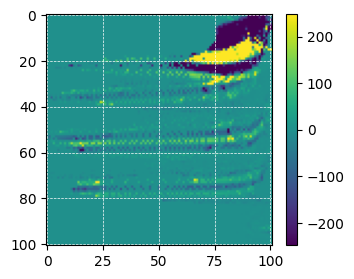

In [83]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(CIGs,perc=95)

### avg vel

In [107]:
!cat mute_dir

0        2000
0        0
0  0

0        2000
0.219    0.942
1  0.2

END


In [113]:
!cp setup_default setup
!echo "FILE_MODEL  avg" >> setup
!echo "WEIGHTING   polygon:mute_dir" >> setup
!echo "DIR_OUT     results_avg" >> setup
run(app='../../exe/rtm_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2556592 Jun 26 18:29 ../../exe/rtm_AC_FDSG_O4_
 Git Commit: 3bc2a52
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2025
System time: 19:48:43
System timezone: +08:00
                        
       WELCOME TO SeisJIMU RTM        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_wrong
 Output directory:results_wrong/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or

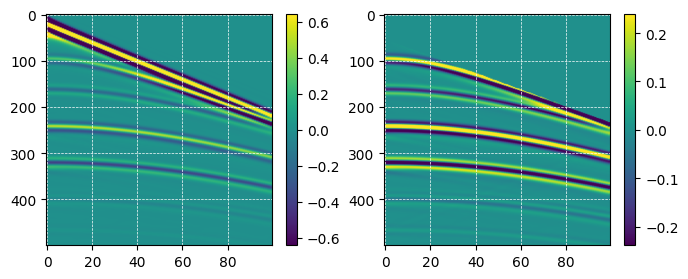

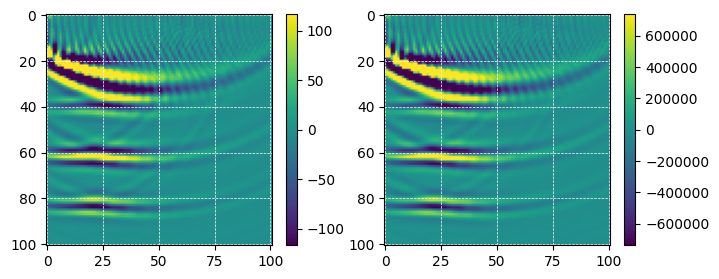

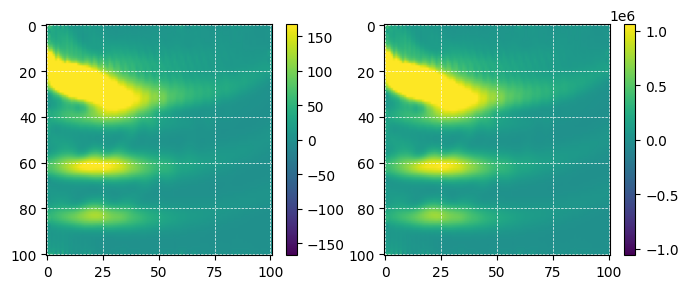

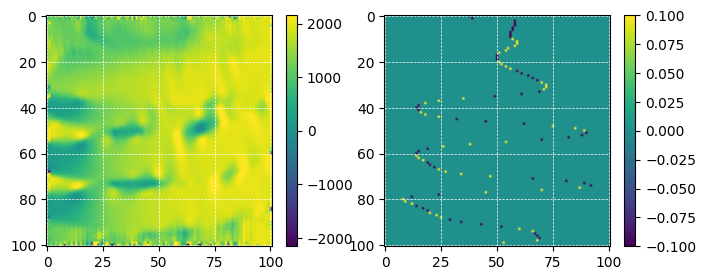

In [114]:
## plot
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read_su('./results_obs/Ru_Shot0001.su') ,perc=95)
plt.subplot(1,2,2); imshow(read_su('./results_avg/dadj_Shot0001.su'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_avg/a_star_u%ipp'),perc=95)
plt.subplot(1,2,2); imshow(read('results_avg/a2_star_u%ipp'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_wrong/imag1'),perc=95)
plt.subplot(1,2,2); imshow(read('results_wrong/imag2'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_wrong/offset_map'),perc=98)
plt.subplot(1,2,2); imshow(read('results_wrong/CIGs'),perc=98)

In [115]:
RTMimage  = read('results_avg/a_star_u%ipp')
ATTRimage = read('results_avg/a2_star_u%ipp')

imag1=read('results_avg/imag1'); thres1=1e-6*np.max(imag1)
imag2=read('results_avg/imag2'); thres2=1e-6*np.max(imag2)

offset_map = read('results_avg/offset_map')
CIGs = read('results_avg/CIGs')

for ix in range(nx):
    for iz in range(nz):
        if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            ih = int(np.abs( offset_map[iz,ix]/h ) )
            print(iz,ix,ih)
            if ih<101:
                CIGs[iz,ih] += RTMimage[iz,ix]

0 0 20
1 0 27
2 0 62
3 0 55
4 0 71
5 0 75
6 0 84
7 0 99
8 0 90
9 0 85
10 0 79
11 0 76
12 0 75
13 0 72
14 0 69
15 0 67
16 0 66
17 0 65
18 0 67
19 0 74
20 0 86
21 0 102
22 0 114
23 0 114
24 0 101
25 0 82
26 0 78
27 0 82
28 0 73
29 0 70
30 0 58
31 0 44
32 0 48
33 0 12
34 0 19
35 0 815
36 0 90
37 0 36
38 0 10
39 0 8
40 0 18
41 0 2
42 0 37
43 0 54
44 0 54
45 0 44
46 0 63
47 0 78
48 0 75
49 0 85
50 0 91
51 0 83
52 0 94
53 0 96
54 0 79
55 0 48
56 0 13
57 0 11
58 0 5
59 0 4
60 0 6
61 0 9
62 0 11
63 0 11
64 0 9
65 0 4
66 0 4
67 0 19
68 0 90
69 0 231
70 0 124
71 0 94
72 0 92
73 0 98
74 0 90
75 0 86
76 0 75
77 0 48
78 0 30
79 0 21
80 0 13
81 0 12
82 0 13
83 0 10
84 0 5
85 0 3
86 0 5
87 0 14
88 0 27
89 0 21
90 0 22
91 0 91
92 0 71
93 0 47
94 0 59
95 0 68
96 0 56
97 0 58
98 0 50
99 0 46
100 0 31
0 1 52
1 1 55
2 1 68
3 1 110
4 1 67
5 1 59
6 1 63
7 1 53
8 1 57
9 1 65
10 1 75
11 1 86
12 1 87
13 1 85
14 1 82
15 1 78
16 1 76
17 1 75
18 1 76
19 1 78
20 1 83
21 1 87
22 1 89
23 1 88
24 1 84
25 1 79
26 1 73

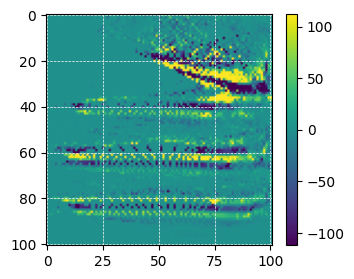

In [116]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(CIGs,perc=95)

### wrong vel

In [107]:
!cat mute_dir

0        2000
0        0
0  0

0        2000
0.219    0.942
1  0.2

END


In [123]:
!cp setup_default setup
!echo "FILE_MODEL  wrong" >> setup
!echo "WEIGHTING   polygon:mute_dir" >> setup
!echo "DIR_OUT     results_wrong" >> setup
run(app='../../exe/rtm_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2556592 Jun 26 18:29 ../../exe/rtm_AC_FDSG_O4_
 Git Commit: 3bc2a52
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2025
System time: 19:53:56
System timezone: +08:00
                        
       WELCOME TO SeisJIMU RTM        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_wrong
 Output directory:results_wrong/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or

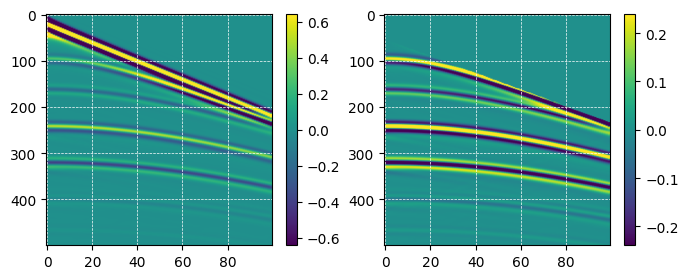

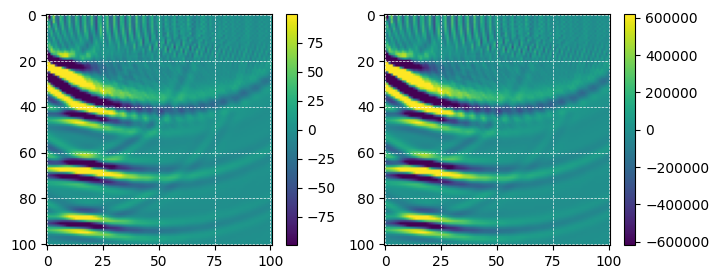

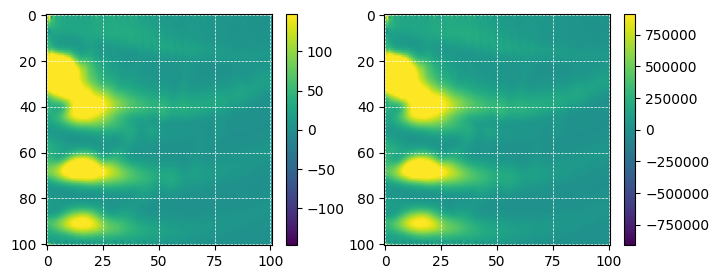

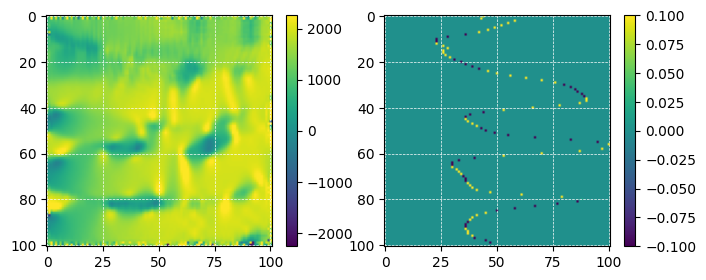

In [124]:
## plot
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read_su('./results_obs/Ru_Shot0001.su') ,perc=95)
plt.subplot(1,2,2); imshow(read_su('./results_wrong/dadj_Shot0001.su'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_wrong/a_star_u%ipp'),perc=95)
plt.subplot(1,2,2); imshow(read('results_wrong/a2_star_u%ipp'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_wrong/imag1'),perc=95)
plt.subplot(1,2,2); imshow(read('results_wrong/imag2'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_wrong/offset_map'),perc=98)
plt.subplot(1,2,2); imshow(read('results_wrong/CIGs'),perc=98)

In [127]:
RTMimage  = read('results_wrong/a_star_u%ipp')
ATTRimage = read('results_wrong/a2_star_u%ipp')

imag1=read('results_wrong/imag1'); thres1=1e-6*np.max(imag1)
imag2=read('results_wrong/imag2'); thres2=1e-6*np.max(imag2)

offset_map = read('results_wrong/offset_map')
CIGs = read('results_wrong/CIGs')

for ix in range(nx):
    for iz in range(nz):
        # if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            ih = int(np.abs( offset_map[iz,ix]/h ) )
            print(iz,ix,ih)
            if ih<101:
                CIGs[iz,ih] += RTMimage[iz,ix]

0 0 35
1 0 32
2 0 32
3 0 34
4 0 42
5 0 31
6 0 13
7 0 34
8 0 17
9 0 35
10 0 29
11 0 35
12 0 25
13 0 33
14 0 48
15 0 49
16 0 53
17 0 55
18 0 55
19 0 53
20 0 52
21 0 52
22 0 51
23 0 51
24 0 53
25 0 54
26 0 57
27 0 61
28 0 65
29 0 70
30 0 76
31 0 79
32 0 80
33 0 73
34 0 69
35 0 72
36 0 72
37 0 78
38 0 93
39 0 95
40 0 87
41 0 78
42 0 58
43 0 29
44 0 5
45 0 8
46 0 16
47 0 27
48 0 40
49 0 32
50 0 9
51 0 78
52 0 121
53 0 124
54 0 103
55 0 92
56 0 89
57 0 80
58 0 85
59 0 90
60 0 82
61 0 70
62 0 51
63 0 30
64 0 15
65 0 6
66 0 2
67 0 2
68 0 5
69 0 7
70 0 9
71 0 12
72 0 15
73 0 18
74 0 26
75 0 28
76 0 65
77 0 109
78 0 92
79 0 87
80 0 96
81 0 103
82 0 110
83 0 120
84 0 120
85 0 83
86 0 28
87 0 11
88 0 22
89 0 13
90 0 1
91 0 4
92 0 11
93 0 12
94 0 6
95 0 5
96 0 17
97 0 38
98 0 40
99 0 44
100 0 36
0 1 50
1 1 44
2 1 42
3 1 46
4 1 49
5 1 43
6 1 23
7 1 94
8 1 19
9 1 38
10 1 41
11 1 46
12 1 45
13 1 45
14 1 49
15 1 53
16 1 57
17 1 59
18 1 57
19 1 54
20 1 52
21 1 50
22 1 49
23 1 48
24 1 49
25 1 50
26 1 53


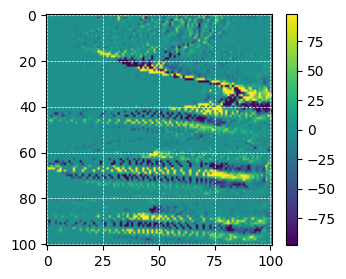

In [128]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(CIGs,perc=95)